# Black-box MCP agent configuration

A Llama-3.2-3B model reads a task and picks the MCP servers for a GPT-4.1-mini agent: one digit per capability slot
(4 slots, 3 servers each, 0 = none, at most 2 attached), so 256 configurations. The reward is 1 if the agent then
finished the task and used every server it was given, else 0. Only 1-3 of the 256 configurations succeed per task.


Needs one GPU and access to `meta-llama/Llama-3.2-3B-Instruct` (put `HF_TOKEN` in `.env`). One run takes 1-3 minutes,
so all 140 runs take about 5 hours on one GPU. To split them over k GPUs, run k copies of this notebook headless, with
`WORKER=i/k` and `CUDA_VISIBLE_DEVICES=i` set for copy i. Finished runs are saved and skipped.

In [1]:
import os; os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
import sys, json, itertools, collections, time
from types import SimpleNamespace
import numpy as np, torch, matplotlib.pyplot as plt
from dotenv import load_dotenv; load_dotenv(".env")
from mcp_live import workspace, catalog, tasks as task_lib
sys.path.insert(0, ".."); from baselines import group_weights

TRAIN   = ["port", "digest", "defines", "lint"]       # the four tasks the base agent can solve
SEEDS   = range(20)
LR      = 0.045                                       # plain SGD, per step
BUDGET  = 400                                         # agent episodes per run
GROUP   = 4                                           # episodes per task per step for RLOO, GRPO and OTB (1 for the others)
N_OFF   = 50                                          # offline episodes per task
OFFLINE = "_sgd_long/offline_data.json"               # the offline dataset
WARM    = "_sgd_long/warm_offline/warm.pt"            # the warm start
OUT     = "_sgd_long/offline_lr0.045"                 # one .npy per method and seed: (episodes, P(success)) per step
OUT_GROUP = "_sgd_long/offline_lr0.045_fix"           # the same for RLOO, GRPO and OTB
WORKER  = os.environ.get("WORKER", "0/1")             # "i/k": this copy runs every k-th job, from the i-th

SLOTS, CAP = catalog.SLOTS, catalog.BUDGET            # 4 slots x 3 servers; the client attaches at most 2
CONFIGS = list(itertools.product(range(4), repeat=4)) # one digit per slot, 0 = none
OVER_CAP = np.array([sum(d > 0 for d in c) > CAP for c in CONFIGS])
TASKS = {t["id"]: t for t in task_lib.make_tasks(workspace.build_template(), workspace.start_intranet())}
SERVERS = json.load(open("mcp_live/catalog.json"))    # what each server announces about itself over MCP

## The reward table

Each cached episode records the agent's transcript, the servers it was given and called, and whether the task's checker
passed. The reward of a configuration is the mean over its two runs; configurations over the cap were never run and score 0.

In [2]:
episodes = [json.loads(line) for line in open("_live_rewards_gpt-4.1-mini_transcripts.jsonl")]

def reward(ep):                                                  # 1 if the checker passed and every attached server was used
    used = {call.split("__")[0] for call in ep["calls"]}
    return float(ep["f"] and set(ep["servers"]) <= used)

runs = collections.defaultdict(list)
for ep in episodes:
    runs[ep["task"], tuple(ep["config"])].append(reward(ep))
REWARD = {t: np.array([np.mean(runs.get((t, c), [0.0])) for c in CONFIGS]) for t in TASKS}
for t in TRAIN:
    print(f"{t:<8} {int((REWARD[t] > 0).sum())} of 256 configurations succeed")

port     2 of 256 configurations succeed
digest   1 of 256 configurations succeed
defines  3 of 256 configurations succeed
lint     3 of 256 configurations succeed


## The model

Rank-8 LoRA on the down projection of the last layer, about 90k trainable parameters. The model writes the whole answer;
`fill` turns a configuration into the answer's tokens.

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

MODEL = "meta-llama/Llama-3.2-3B-Instruct"
tok = AutoTokenizer.from_pretrained(MODEL, clean_up_tokenization_spaces=False)
base = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float32).cuda().requires_grad_(False)
torch.manual_seed(0)                                             # lora_A's random draw sets the gradient geometry: fix it
model = get_peft_model(base, LoraConfig(r=8, lora_alpha=16, target_modules=["down_proj"], layers_to_transform=[27])).eval()
params = [p for n, p in model.named_parameters() if "lora" in n]
start_params = [p.detach().clone() for p in params]
def reset():
    for p, p0 in zip(params, start_params): p.data.copy_(p0)

SYSTEM = ("You configure the MCP servers of an autonomous agent that will carry out a small task in a project workspace. "
          "There are four capability slots; each offers three servers, and 0 leaves the slot empty. The client attaches at most "
          f"{CAP} servers in total: a configuration with more than {CAP} is rejected and the task fails. Attach exactly the "
          "servers the task needs: the agent can only use what you attach, and a missing or wrong server makes the task "
          "impossible. Answer with one line per slot, in the order given, in exactly this form:\n"
          + "\n".join(f"{slot}: <0|1|2|3>" for slot, _ in SLOTS) + "\nEND")

def legend(slot, names):
    return f"{slot}: 0 = no server; " + "; ".join(
        f"{i + 1} = {n} ({SERVERS[n]['instructions'].rstrip('.')}; tools: {', '.join(t['name'] for t in SERVERS[n]['tools'])})"
        for i, n in enumerate(names))

PREFILL = "files: "
enc = lambda s: tok.encode(s, add_special_tokens=False)
def prompt_ids(task_id):
    user = f"Task: {TASKS[task_id]['spec']}\nSlots:\n" + "\n".join(legend(s, n) for s, n in SLOTS)
    chat = tok.apply_chat_template([{"role": "system", "content": SYSTEM}, {"role": "user", "content": user}], tokenize=False, add_generation_prompt=True)
    return enc(chat + PREFILL)

DIGITS = [enc(str(d))[0] for d in range(4)]
TEMPLATE = []
for j, (slot, _) in enumerate(SLOTS):
    TEMPLATE += (enc(f"\n{slot}: ") if j else []) + [None]
fill = lambda template, digits: [DIGITS[digits[template[:i].count(None)]] if t is None else t for i, t in enumerate(template)]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

## Every answer at once

`build_tree` scores every prefix of every answer in one batched forward pass. For each (prefix, token) entry it stores
the probability and the score (the gradient of its log-probability), so the policy's distribution over all answers and
any expectation under it are exact. Any token that breaks the answer format is one extra branch, scored 0.

In [4]:
lm, last = model.base_model.model, model.base_model.model.model.layers[-1]
dp = last.mlp.down_proj                                          # the one layer that is trained
LA, LB, SC = dp.lora_A.default.weight, dp.lora_B.default.weight, dp.scaling["default"]
saved = {}
last.post_attention_layernorm.register_forward_pre_hook(lambda m, a: saved.update(r=a[0]))    # the residual stream
dp.register_forward_pre_hook(lambda m, a: saved.update(x=a[0]))                               # the LoRA's input

def build_tree(task_id, chunk=64):
    prompt = prompt_ids(task_id)
    steps = list(range(len(TEMPLATE)))                                                      # every position of the answer is scored
    nodes = [(k, d) for k in steps for d in itertools.product(range(4), repeat=TEMPLATE[:k].count(None))]
    allowed = [DIGITS if TEMPLATE[k] is None else [TEMPLATE[k]] for k, _ in nodes]         # plus one branch: anything else
    size = [len(a) + 1 for a in allowed]; first = np.cumsum([0] + size[:-1]); E = sum(size)

    leaves = []                                                  # (entries taken on the way, configuration index or -1)
    def walk(i, digits, path):
        n = nodes.index((steps[i], digits)); A = len(allowed[n])
        leaves.append((path + [first[n] + A], -1))                                          # anything else
        for j in range(A):
            nxt = digits + (j,) if A == 4 else digits
            if i + 1 < len(steps): walk(i + 1, nxt, path + [first[n] + j])
            else: leaves.append((path + [first[n] + j], CONFIGS.index(nxt)))
    walk(0, (), [])
    node_first, node_size = np.repeat(first, size), np.repeat(size, size)
    taken, passed = np.zeros((len(leaves), E)), np.zeros((len(leaves), E))                 # passed: every branch of every node on the way
    for y, (path, _) in enumerate(leaves):
        taken[y, path] = 1
        for e in path: passed[y, node_first[e]:node_first[e] + node_size[e]] = 1

    # One forward: the 64 answers that spell out every choice of the first three digits contain every prefix in the tree.
    lines = list(itertools.product(range(4), repeat=TEMPLATE.count(None) - 1))
    with torch.no_grad():
        kv = lm.model(input_ids=torch.tensor([prompt[:-1]], device="cuda")).past_key_values; kv.batch_repeat_interleave(len(lines))
        lm.model(input_ids=torch.tensor([prompt[-1:] + fill(TEMPLATE[:-1], d) for d in lines], device="cuda"), past_key_values=kv)
    X, R = saved["x"], saved["r"]                                                          # (64, 16, .): position k predicts TEMPLATE[k]
    at = [(lines.index(d + (0,) * (len(lines[0]) - len(d))), k) for k, d in nodes]

    P = torch.zeros(E, dtype=torch.float64, device="cuda"); Z = torch.zeros(E, sum(p.numel() for p in params), device="cuda")
    U = torch.zeros(E, R.shape[-1], device="cuda")                                         # the backprop signal behind every score
    W = lm.lm_head.weight
    for A1 in sorted(set(size)):
        group = [n for n in range(len(nodes)) if size[n] == A1]
        for c in range(0, len(group), chunk):
            g = group[c:c + chunk]; B = len(g); s, k = map(list, zip(*[at[n] for n in g]))
            v = R[s, k][:, None] + dp(X[s, k][:, None])                                    # the vector the LoRA writes into
            h = lm.model.norm(v)[:, 0]                                                     # (B, d), carries the LoRA gradient
            with torch.no_grad():
                logp = torch.log_softmax(lm.lm_head(h), -1); p = logp.exp()
                ok = torch.tensor([allowed[n] for n in g], device="cuda")
                rest = torch.ones_like(p).scatter_(1, ok, 0.0)                                # the tokens that break the answer
                lp = torch.cat([logp.gather(1, ok), (logp + rest.log()).logsumexp(-1, keepdim=True)], 1)
                q = p * rest / (p * rest).sum(-1, keepdim=True).clamp_min(1e-30)
                dlp_dh = torch.cat([W[ok], (q @ W)[:, None]], 1) - (p @ W)[:, None]          # d log p(branch) / d h, (B, A1, d)
            onehot = torch.zeros(B * A1, B, h.shape[1], device="cuda")
            onehot[torch.arange(B * A1), torch.arange(B).repeat_interleave(A1)] = dlp_dh.reshape(B * A1, -1)
            gs = torch.autograd.grad(h, [v] + params, onehot, is_grads_batched=True)         # one score per branch, and the signal behind it
            rows = torch.tensor([first[n] + a for n in g for a in range(A1)], device="cuda")
            pr = lp.double().exp(); P[rows] = (pr / pr.sum(1, keepdim=True)).flatten()
            Z[rows] = torch.cat([x.reshape(B * A1, -1) for x in gs[1:]], 1)
            U[rows] = gs[0][torch.arange(B * A1), torch.arange(B).repeat_interleave(A1), 0]
            del onehot, gs

    T = lambda a: torch.tensor(a, dtype=torch.float64, device="cuda")
    node = torch.tensor(np.repeat(np.arange(len(nodes)), size), device="cuda")              # the node of every entry
    tree = SimpleNamespace(P=P, Z=Z, K=(Z @ Z.T).double(), taken=T(taken), passed=T(passed), N=len(nodes), node=node,
                           conf=np.array([c for _, c in leaves]))
    tree.pb = torch.exp(tree.taken @ torch.log(P.clamp_min(1e-300)))                        # probability of every leaf

    # The row structure.  A linear layer's gradient is (backprop signal) x (layer input), so the score of branch e at prefix n is
    # gA[e] (x) x_n on lora_A's rows and u[e] (x) z_n on lora_B's rows: inside one row every branch of n writes along the SAME vector.
    with torch.no_grad():
        s_at, k_at = map(list, zip(*at)); xn = X[s_at, k_at].double(); zn = SC * (xn @ LA.double().T)
        tree.gA, tree.gB = SC * (U.double() @ LB.double()), U.double()
        tree.XX, tree.ZZ = (xn @ xn.T)[node][:, node], (zn @ zn.T)[node][:, node]           # <x_n, x_n'> and <z_n, z_n'>, per pair of entries
        tree.nx, tree.nz = tree.XX.diagonal().sqrt(), tree.ZZ.diagonal().sqrt()
        tree.xhat, tree.zhat = xn / xn.norm(dim=1, keepdim=True), zn / zn.norm(dim=1, keepdim=True)
    return tree

def leaf_rewards(tree, table):                                   # a table over the 256 configurations -> one reward per leaf
    return torch.tensor(np.where(tree.conf >= 0, table[np.maximum(tree.conf, 0)], 0.0), device="cuda")

def sample(tree, n, rng):
    return rng.choice(len(tree.conf), size=n, p=(tree.pb / tree.pb.sum()).cpu().numpy())

## The estimators

With a table c over (prefix, token) entries, one episode y gives the gradient estimate `weights(tree, c, f)[y] @ Z`.
c = 0 is REINFORCE; c = Q (the expected reward after each prefix and token, computed from f-hat) is the Q estimator.
Q + Δ* also subtracts a row-wise residual: inside one weight row every branch's score points along the same vector
(the layer's input), so one scalar per (prefix, token, row) cancels that whole component of the noise. The residual has
mean zero at every prefix, so the estimator stays unbiased for any f-hat.

f-hat is the mean paid reward of each configuration, with one pseudo-failure (an untried configuration is assumed to fail).

In [5]:
def weights(tree, c, f):             # g_hat(y) = weights[y] @ Z, for every leaf y at once
    return tree.taken * (f[:, None] - c) + tree.passed * (tree.P * c)

def Q_table(tree, f):                # E[f | the answer reached this prefix and wrote this token]
    n = tree.pb @ tree.taken
    return torch.where(n > 0, (tree.pb * f) @ tree.taken / n.clamp_min(1e-300), 0.0)

def increments(tree, c, f):          # how the estimator's conditional mean moves when the answer takes branch e at its prefix
    A = weights(tree, c, f); n = tree.pb @ tree.taken
    cond = ((tree.taken * tree.pb[:, None]).T @ A) / n.clamp_min(1e-300)[:, None]            # E[weights | e taken]
    mean = torch.zeros(tree.N, A.shape[1], dtype=A.dtype, device=A.device).index_add_(0, tree.node, tree.P[:, None] * cond)
    return cond - mean[tree.node]                                                            # zero mean over the branches of every prefix

def row_parts(tree, xi, e=slice(None)):   # the component of the increments along the layer input, row by row
    return xi * tree.XX[e] / tree.nx[e][:, None], xi * tree.ZZ[e] / tree.nz[e][:, None]

def row_correction(tree, xi, y):     # what one episode subtracts: the projected increment at every prefix on its path
    e = tree.taken[y].nonzero().squeeze(1); n = tree.node[e]
    cA, cB = row_parts(tree, xi[e], e)
    return torch.cat([torch.einsum("eq,ej->qj", cA @ tree.gA, tree.xhat[n]).flatten(),
                      torch.einsum("ei,eq->iq", cB @ tree.gB, tree.zhat[n]).flatten()])

class Seen:                          # the paid episodes so far, as f-hat per configuration
    def __init__(self):
        self.n, self.sum = np.zeros(len(CONFIGS)), np.zeros(len(CONFIGS))
    def add(self, conf, f):
        if conf >= 0: self.n[conf] += 1; self.sum[conf] += f
    def f_hat(self, prior=1.0):      # untried = fails; over the cap: the client's rule, a known 0
        return np.where(OVER_CAP, 0.0, self.sum / (self.n + prior))

def control_variate(method, tree, seen):   # the table c, and for Q + Δ* the increments its residual is built from
    if method == "REINFORCE": return torch.zeros_like(tree.P), None
    f_hat = leaf_rewards(tree, seen.f_hat()); Q = Q_table(tree, f_hat)
    return Q, (increments(tree, Q, f_hat) if method == "Q + rowΔ" else None)

def decisions(tree, ys):             # each leaf as its sequence of decisions, for the group baselines
    return torch.nn.utils.rnn.pad_sequence([tree.taken[y].nonzero().squeeze(1) for y in ys], batch_first=True, padding_value=-1)

def estimate(method, tree, ys, f, seen):
    if method in ("RLOO", "GRPO", "OTB"):                                    # the group of episodes is the baseline
        pos = decisions(tree, ys)
        return group_weights(method, f[ys], (pos >= 0).double(), pos, tree.K.diagonal()).float() @ tree.Z
    if method == "exact gradient":                                           # the reference: the true table's gradient
        return ((tree.pb * f) @ tree.taken).float() @ tree.Z
    c, xi = control_variate(method, tree, seen)
    g = weights(tree, c, f)[ys].mean(0).float() @ tree.Z
    if xi is not None: g = g - torch.stack([row_correction(tree, xi, y) for y in ys]).mean(0).float()
    return g

## The offline dataset and the warm start

50 episodes per task from the base model, scored once. Every method's f-hat starts from them. The warm start takes
supervised steps on the dataset's successful episodes until mean P(success) reaches 0.35. Both are saved and reused.

In [6]:
def p_success():
    ps = []
    for t in TRAIN:
        tree = build_tree(t); ps.append(float(tree.pb @ leaf_rewards(tree, REWARD[t]))); del tree
    return ps

if not os.path.exists(OFFLINE):
    reset(); rng = np.random.default_rng(2026); data = []
    for t in TRAIN:
        tree = build_tree(t); f = leaf_rewards(tree, REWARD[t])
        data += [(t, int(tree.conf[y]), float(f[y])) for y in sample(tree, N_OFF, rng)]; del tree
    json.dump({"n_per_task": N_OFF, "seed": 2026, "tasks": TRAIN, "episodes": [[t, c] for t, c, _ in data], "f_strict": [r for _, _, r in data]},
              open(OFFLINE, "w"))
data = json.load(open(OFFLINE))
print(f"offline dataset: {len(data['episodes'])} episodes, {sum(r > 0 for r in data['f_strict'])} succeed")

if not os.path.exists(WARM):
    def sft_loss(task, digits):                                  # cross-entropy of the answer after the prompt
        prompt = prompt_ids(task); answer = fill(TEMPLATE, digits)
        ids = torch.tensor([prompt + answer], device="cuda"); labels = torch.tensor([[-100] * len(prompt) + answer], device="cuda")
        return lm(input_ids=ids, labels=labels).loss
    reset(); good = {t: [c for (tt, c), r in zip(data["episodes"], data["f_strict"]) if tt == t and r > 0] for t in TRAIN}
    tasks = [t for t in TRAIN if good[t]]; rng = np.random.default_rng(1000); opt = torch.optim.Adam(params, lr=5e-4); ps = p_success()
    for step in range(60):
        if np.mean(ps) >= 0.35: break
        opt.zero_grad(); (sum(sft_loss(t, CONFIGS[rng.choice(good[t])]) for t in tasks) / len(tasks)).backward(); opt.step()
        ps = p_success()
    os.makedirs(os.path.dirname(WARM), exist_ok=True); torch.save([p.detach().cpu().clone() for p in params], WARM)
warm = torch.load(WARM)

offline dataset: 200 episodes, 31 succeed


## Run

In [7]:
METHODS = ["REINFORCE", "RLOO", "GRPO", "OTB", "Q", "Q + rowΔ", "exact gradient"]
LABEL = {"Q + rowΔ": "Q + Δ*"}
path = lambda m, s: os.path.join(OUT_GROUP if m in ("RLOO", "GRPO", "OTB") else OUT,
                                 f"{m.replace(' ', '').replace('+', 'p')}_s{s}.npy")

def train(method, seed):
    K = GROUP if method in ("RLOO", "GRPO", "OTB") else 1; steps = BUDGET // (K * len(TRAIN))
    reset(); rng = np.random.default_rng(seed)
    for p, w in zip(params, warm): p.data.copy_(w.to(p.device))
    opt = torch.optim.SGD(params, lr=LR)
    seen = {t: Seen() for t in TRAIN}
    for t, conf in data["episodes"]: seen[t].add(conf, float(REWARD[t][conf]))
    log, dead = [], False
    for step in range(steps + 1):
        grad, success = 0.0, []
        for t in (TRAIN if not dead else []):
            tree = build_tree(t); f = leaf_rewards(tree, REWARD[t])
            if not torch.isfinite(tree.pb).all(): dead = True; del tree; break         # the last step sent the weights to NaN
            success.append(float(tree.pb @ f))
            ys = sample(tree, K, rng)
            grad = grad + estimate(method, tree, ys, f, seen[t]) / len(TRAIN)
            for y in ys: seen[t].add(tree.conf[y], float(f[y]))
            del tree
        log.append((step * K * len(TRAIN), 0.0 if dead else np.mean(success)))      # a run that blew up scores 0 from there on
        if dead or step == steps: continue
        opt.zero_grad()
        for p, g in zip(params, (-grad).split([p.numel() for p in params])): p.grad = g.view_as(p)
        opt.step()
    return np.array(log)

me, k = map(int, WORKER.split("/"))
todo = [(m, s) for m in METHODS for s in SEEDS][me::k]
todo = [(m, s) for m, s in todo if not os.path.exists(path(m, s))]
print(f"{len(todo)} runs to do")
for m, s in todo:
    t0 = time.time(); log = train(m, s)
    os.makedirs(os.path.dirname(path(m, s)), exist_ok=True); np.save(path(m, s), log)
    print(f"{m:15s} seed {s}: P(success) {log[0, 1]:.3f} -> {log[-1, 1]:.3f}  ({time.time() - t0:.0f}s)", flush=True)

0 runs to do


REINFORCE       P(success): mean over the run 0.301, final 0.363, 20 seeds
RLOO            P(success): mean over the run 0.399, final 0.400, 20 seeds
GRPO            P(success): mean over the run 0.306, final 0.348, 20 seeds


OTB             P(success): mean over the run 0.489, final 0.574, 20 seeds
Q               P(success): mean over the run 0.710, final 0.823, 20 seeds


Q + Δ*          P(success): mean over the run 0.753, final 0.864, 20 seeds
exact gradient  P(success): mean over the run 0.766, final 0.868, 20 seeds


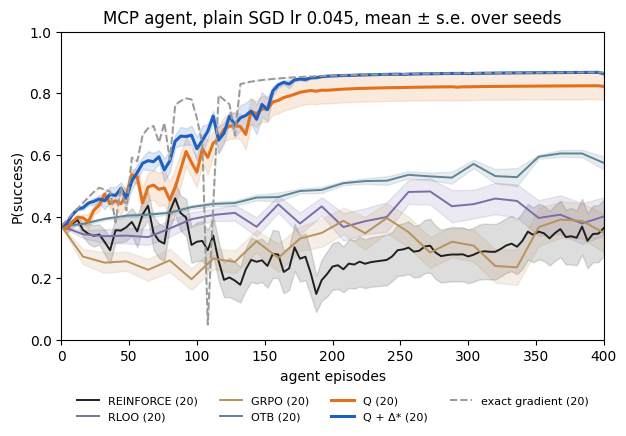

In [8]:
COL = {"REINFORCE": "#1f1f1f", "RLOO": "#7a6ea8", "GRPO": "#b8925a", "OTB": "#5f8496", "LAX": "#6e8b5e", "RELAX": "#6e8b5e", "V": "#c2648a",
       "Q": "#e2711d", "Q + Δ*": "#1f5fbf", "exact gradient": "#9a9994"}                  # the paper's colors
fig, ax = plt.subplots(figsize=(7, 4))
for m in METHODS:
    files = [path(m, s) for s in SEEDS if os.path.exists(path(m, s))]
    if not files: continue
    L = np.stack([np.load(f) for f in files]); keep = L[0, :, 0] <= BUDGET; x, S = L[0, keep, 0], L[:, keep, 1]
    mean, se = S.mean(0), S.std(0, ddof=1) / np.sqrt(len(S)) if len(S) > 1 else 0 * S[0]
    ax.plot(x, mean, ls="--" if m == "exact gradient" else "-", lw=2.2 if m.startswith("Q") else 1.4, color=COL[LABEL.get(m, m)], label=f"{LABEL.get(m, m)} ({len(S)})")
    ax.fill_between(x, mean - se, mean + se, color=COL[LABEL.get(m, m)], alpha=0.15)
    print(f"{LABEL.get(m, m):15s} P(success): mean over the run {S.mean():.3f}, final {S[:, -1].mean():.3f}, {len(S)} seeds")
ax.set(xlabel="agent episodes", ylabel="P(success)", xlim=(0, BUDGET), ylim=(0, 1),
       title=f"MCP agent, plain SGD lr {LR}, mean ± s.e. over seeds")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8, frameon=False); plt.show()